### **1. Install tacoreader**

## **2. Load a TACO compliant dataset**

In [1]:
import autoroot
import tacoreader
from shapely import wkb
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import pathlib

import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch import LightningDataModule
from loguru import logger

from src.finetuning.dataloader import Cloud3DDataModule
from src.finetuning.transforms import GeoSatTransform
from src.finetuning.model import UNetAutoencoder


In [2]:
tacoreader.use("pandas")

folder= "/home/emiliano/Documents/3DClouds_data/tacos/finetune/"
tacoreader.use("pandas")                      
goes = tacoreader.load(folder+"goes/")
himawari = tacoreader.load(folder+"himawari/")
msg = tacoreader.load(folder+"msg/")


# Concat
full_dataset = tacoreader.concat([goes, himawari, msg])
dataset = full_dataset.data#.to_pandas()



In [3]:
SPLITS_DICT = {
    "train": {
        "years": np.arange(2004, 2025).tolist(),
        "months": np.arange(1, 13).tolist(),
        "days": np.arange(2, 23).tolist(),
    },
    "val": {
        "years": np.arange(2004, 2025).tolist(),
        "months": np.arange(1, 13).tolist(),
        "days": np.arange(24, 27).tolist(),
    },
    "test": {
        "years": np.arange(2004, 2025).tolist(),
        "months": np.arange(1, 13).tolist(),
        "days": np.arange(28, 32).tolist(),
    },
}

def add_split_column(df: pd.DataFrame, date_col: str = "date", split_col: str = "split") -> pd.DataFrame:
    #df = df.copy()

    # ensure datetime
    df[date_col] = pd.to_datetime(df[date_col])

    y = df[date_col].dt.year
    m = df[date_col].dt.month
    d = df[date_col].dt.day

    # start with NaN / unknown
    split = np.full((len(df),), np.nan, dtype=object)
    #split = pd.Series(pd.NA, index=df.index, dtype="string")

    for name, spec in SPLITS_DICT.items():
        mask = (
            y.isin(spec["years"]) &
            m.isin(spec["months"]) &
            d.isin(spec["days"])
        )
        #split.loc[mask] = name
        split[mask] = name

    df[split_col] = split
    return df


In [4]:
dataset = add_split_column(dataset, date_col="stac:time_start", split_col="split")
dataset

                       cloud3d:cloudsat_id  cloud3d:cyclone  \
0   2018283153908_66322_CS_merged_no_flxhr            False   
1   2018283153908_66322_CS_merged_no_flxhr            False   
2   2018285151645_66351_CS_merged_no_flxhr            False   
3   2018293152524_66468_CS_merged_no_flxhr            False   
4   2018293152524_66468_CS_merged_no_flxhr            False   
..                                     ...              ...   
95  2019081152809_68704_CS_merged_no_flxhr            False   
96  2019081152809_68704_CS_merged_no_flxhr            False   
97  2019084154336_68748_CS_merged_no_flxhr            False   
98  2019084154336_68748_CS_merged_no_flxhr            False   
99  2019086152104_68777_CS_merged_no_flxhr            False   

                             cloud3d:geostationary_id  cloud3d:has_flxhr  \
0   OR_ABI-L2-MCMIPF-M3_G16_s20182831615382_e20182...              False   
1   OR_ABI-L2-MCMIPF-M3_G16_s20182831615382_e20182...              False   
2   OR_ABI-L2-M

In [5]:
transform = GeoSatTransform(patch_size=[256, 256])
dm = Cloud3DDataModule(dataset, transform)

2026-03-16 16:35:49.500 | INFO     | src.finetuning.dataloader:__init__:28 - There are 270072 files in taco dataset
2026-03-16 16:35:50.176 | INFO     | src.finetuning.dataloader:__init__:57 - MSG DataModule initialized ...
2026-03-16 16:35:50.177 | INFO     | src.finetuning.dataloader:__init__:58 - Length of train dataset: 185629
2026-03-16 16:35:50.177 | INFO     | src.finetuning.dataloader:__init__:59 - Length of test dataset: 31166
2026-03-16 16:35:50.178 | INFO     | src.finetuning.dataloader:__init__:60 - Length of val dataset: 26462


In [6]:
loader = dm.train_dataloader()

In [7]:
batch = next(iter(loader))

In [8]:
batch.keys()

dict_keys(['image', 'cloudsat', 'overpass_mask', 'satellite', 'date', 'id'])

In [9]:
dir_save = "/home/emiliano/Documents/3DClouds_data/pickle_batches/finetune"

In [12]:
import pickle
import numpy as np
# save 100 batches to pickle
for i, batch in enumerate(loader):
    if i >= 100:
        break
    #batch = {k: v.numpy() for k, v in batch.items()}
    with open(f"{dir_save}/batch_{i}.pkl", "wb") as f:
        pickle.dump(batch, f)

In [13]:
# read one batch
with open(f"{dir_save}/batch_0.pkl", "rb") as f:
    batch = pickle.load(f)

In [14]:
batch.keys()

dict_keys(['image', 'cloudsat', 'overpass_mask', 'satellite', 'date', 'id'])

In [15]:
batch["image"].shape

torch.Size([4, 17, 256, 256])

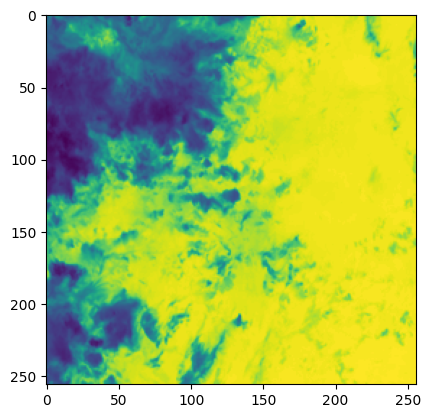

In [16]:
plt.imshow(batch["image"][0,9,])